In [20]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
pip install unidecode

In [22]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import monotonically_increasing_id, split, trim, col, Column, coalesce, isnull, translate, round
from pyspark.sql.functions import avg, col, rand, when, lower, regexp_extract, regexp_replace, expr
import pyspark.sql.functions as F
import pandas as pd
import geopandas as gpd
import unicodedata
from unidecode import unidecode
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import glob
from numpy import quantile
from sklearn.preprocessing import MinMaxScaler
import numpy as np


In [23]:
spark = SparkSession.builder \
    .appName("Analise de Segurança SP") \
    .getOrCreate()
    

In [24]:
# https://www.ssp.sp.gov.br/estatistica/painel-estatistico
# https://drive.google.com/drive/folders/1lyWzon95y_a4H6dmexFT4Vd1GidXxBtD
!ls "/content/drive/MyDrive/Colab Notebooks/Analise_Urbana_SP/BASES/PLANILHA ESTATISTICA POWER AUTOMATE/DADOS 2025"

'01 - DADOS CRIMINAIS_JAN_2025_V2.xlsx'
'02 - DADOS PRODUTIVIDADE_JAN_2025.xlsx'
'03 - DADOS CRIMINAIS_FEV_2025_V3.xlsx'
'04 - DADOS PRODUTIVIDADE_FEV_2025.xlsx'
'05 - DADOS CRIMINAIS_MAR_2025_V3.xlsx'
'06 - DADOS PRODUTIVIDADE_MAR_2025.xlsx'
'07 - DADOS CRIMINAIS_ABR_2025_V2.xlsx'
'08 - DADOS PRODUTIVIDADE_ABR_2025.xlsx'
'09 - DADOS CRIMINAIS_MAI_2025_V3.xlsx'
'10 - DADOS PRODUTIVIDADE_MAI_2025.xlsx'
'11 - DADOS CRIMINAIS_JUN_2025_v2.xlsx'
'12 - DADOS PRODUTIVIDADE_JUN_2025.xlsx'
'13 - DADOS CRIMINAIS_JUL_2025_v2.xlsx'
'14 - DADOS PRODUTIVIDADE_JUL_2025.xlsx'
'15 - DADOS CRIMINAIS_AGO_2025_V3.xlsx'
'16 - DADOS PRODUTIVIDADE_AGO_2025.xlsx'
'17 - DADOS CRIMINAIS_SET_2025_v2.xlsx'
'18 - DADOS PRODUTIVIDADE_SET_2025.xlsx'
'19 - DADOS CRIMINAIS_OUT_2025_V2.xlsx'
'20 - DADOS PRODUTIVIDADE_OUT_2025.xlsx'
'21 - DADOS CRIMINAIS_NOV_25_V3.xlsx'
'22 - DADOS PRODUTIVIDADE_NOV_25.xlsx'
'23 - DADOS CRIMINAIS_DEZ_25_V2.xlsx'
'24 - DADOS PRODUTIVIDADE_DEZ_25_V2.xlsx'


In [25]:
files = glob.glob('/content/drive/MyDrive/Colab Notebooks/Analise_Urbana_SP/BASES/PLANILHA ESTATISTICA POWER AUTOMATE/DADOS 2025/' + '* - DADOS CRIMINAIS_*')
dfs = []

for i in range(12):
    dfs.append(pd.read_excel(files[i]))

df_dados_criminais_pd = pd.concat(dfs, ignore_index=True)
df_dados_criminais_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87358 entries, 0 to 87357
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   2024                   71438 non-null  float64
 1   2025                   70044 non-null  float64
 2   AGRUPAMENTO_NATUREZA2  87358 non-null  object 
 3   NATUREZA2              87358 non-null  object 
 4   AREA                   87358 non-null  object 
 5   DEPARTAMENTO           87358 non-null  object 
 6   SECCIONAL              87358 non-null  object 
 7   DP                     87358 non-null  object 
 8   REGIAO                 87358 non-null  object 
 9   MUNICIPIO              87358 non-null  object 
 10  MES                    87358 non-null  int64  
dtypes: float64(2), int64(1), object(8)
memory usage: 7.3+ MB


In [26]:
df_dados_criminais = spark.createDataFrame(df_dados_criminais_pd)

df_dados_criminais = (df_dados_criminais
                        .select(col("`2024`"), col("`2025`"), "AGRUPAMENTO_NATUREZA2", "NATUREZA2", "AREA","DEPARTAMENTO", "SECCIONAL", "DP", "REGIAO", "MUNICIPIO", "MES")
                        .filter((col("MUNICIPIO") == "São Paulo") & (col("DP") != "Delegacia Aeroporto SP - Congonhas"))
                        .withColumnRenamed("2024", "QTD_CRIMES_2024")
                        .withColumnRenamed("2025", "QTD_CRIMES_2025")
                        .na.fill({'QTD_CRIMES_2024': 0, 'QTD_CRIMES_2025': 0})
                        .withColumn("Distritos", trim(split(col("DP"), "-").getItem(1)))
                        .withColumn("NUM_DP", trim(split(col("DP"), " DP").getItem(0)))
                        .withColumn("NUM_DP", col("NUM_DP").cast("int")))


In [27]:
dados = [
    {"AGRUPAMENTO_NATUREZA2": "FURTO - OUTROS",                     "Categoria_Crime": "PATRIMONIAL"},
    {"AGRUPAMENTO_NATUREZA2": "ROUBO - OUTROS TOTAL",               "Categoria_Crime": "PATRIMONIAL"},
    {"AGRUPAMENTO_NATUREZA2": "FURTO DE VEÍCULO",                   "Categoria_Crime": "PATRIMONIAL"},
    {"AGRUPAMENTO_NATUREZA2": "ROUBO DE VEÍCULO",                   "Categoria_Crime": "PATRIMONIAL"},
    {"AGRUPAMENTO_NATUREZA2": "LESÃO CORPORAL DOLOSA",              "Categoria_Crime": "VIOLÊNCIA PESSOAL"},
    {"AGRUPAMENTO_NATUREZA2": "LESÃO CORPORAL CULPOSA - OUTRAS",    "Categoria_Crime": "VIOLÊNCIA PESSOAL"},
    {"AGRUPAMENTO_NATUREZA2": "ESTUPRO TOTAL",                      "Categoria_Crime": "VIOLÊNCIA SEXUAL"},
    {"AGRUPAMENTO_NATUREZA2": "TENTATIVA DE HOMICÍDIO",             "Categoria_Crime": "VIOLÊNCIA LETAL"},
    {"AGRUPAMENTO_NATUREZA2": "HOMICÍDIO DOLOSO",                   "Categoria_Crime": "VIOLÊNCIA LETAL"},
    {"AGRUPAMENTO_NATUREZA2": "LATROCÍNIO",                         "Categoria_Crime": "VIOLÊNCIA LETAL"},
    {"AGRUPAMENTO_NATUREZA2": "LESÃO CORPORAL SEGUIDA DE MORTE",    "Categoria_Crime": "VIOLÊNCIA LETAL"},
    {"AGRUPAMENTO_NATUREZA2": "Nº DE VÍTIMAS EM HOMICÍDIO DOLOSO",  "Categoria_Crime": "VIOLÊNCIA LETAL"},
    {"AGRUPAMENTO_NATUREZA2": "Nº DE VÍTIMAS EM LATROCÍNIO",        "Categoria_Crime": "VIOLÊNCIA LETAL"}
]

df_agrup_crimes = spark.createDataFrame(dados)

In [31]:
depara_DP = spark.read.parquet("/content/drive/MyDrive/Colab Notebooks/Analise_Urbana_SP/BASES/distritos_bairros/dp_para_distrito_peso.parquet")
depara_DP = depara_DP.withColumn("NUM_DP", col("NUM_DP").cast("int"))

In [32]:
depara_DP.show(5)

+--------------+------+-------+--------------------+--------------------+--------------------+
|       ds_nome|NUM_DP|NM_DP_C|          ds_subpref|            pct_area|       area_intersec|
+--------------+------+-------+--------------------+--------------------+--------------------+
|      PIRITUBA|    74|JARAGUA|    PIRITUBA-JARAGUA| 0.07043158979098567|   1130824.321627048|
|       JARAGUA|    74|JARAGUA|    PIRITUBA-JARAGUA|  0.6659484200182089|1.0692228764685344E7|
|   BRASILANDIA|    74|JARAGUA|FREGUESIA-BRASILA...|  0.2608558885340691|   4188208.502312033|
|FREGUESIA DO O|    74|JARAGUA|FREGUESIA-BRASILA...|0.002429967021329...|  39014.678166793616|
|         PERUS|    74|JARAGUA|               PERUS|3.341346354068715E-4|   5364.745755951062|
+--------------+------+-------+--------------------+--------------------+--------------------+
only showing top 5 rows


In [33]:
acentos = "áàãâäéèêëíìîïóòõôöúùûüçÁÀÃÂÄÉÈÊËÍÌÎÏÓÒÕÔÖÚÙÛÜÇ"
sem_acentos = "aaaaaeeeeiiiiooooouuuucAAAAAEEEEIIIIOOOOOUUUUC"

df_crime_dp = (df_dados_criminais.join(depara_DP, on="NUM_DP", how="left")
                                 .join(df_agrup_crimes, on="AGRUPAMENTO_NATUREZA2", how="left")
                                 .withColumn("CRIMES_2024_POND", col("QTD_CRIMES_2024") * col("pct_area"))
                                 .withColumn("CRIMES_2025_POND", col("QTD_CRIMES_2025") * col("pct_area"))
                                 .withColumn("Bairro_norm",F.upper(F.translate(col("ds_nome"), acentos, sem_acentos)))
                                 .withColumnRenamed("ds_subpref", "Subpref")
                                 .withColumnRenamed("Distritos", "Distrito")
                                 .withColumnRenamed("ds_nome", "Bairro")
                                #  .groupBy(["Subpref",'Bairro_norm'])
                                .groupBy(["Subpref",'Bairro_norm',"Categoria_Crime","AGRUPAMENTO_NATUREZA2"])
                                 .agg(
                                   #    F.sum("CRIMES_2024_POND").alias("QTD_CRIMES_2024"),
                                      F.sum("CRIMES_2025_POND").alias("QTD_CRIMES_2025")))

In [34]:

# acentos = "áàãâäéèêëíìîïóòõôöúùûüçÁÀÃÂÄÉÈÊËÍÌÎÏÓÒÕÔÖÚÙÛÜÇ"
# sem_acentos = "aaaaaeeeeiiiiooooouuuucAAAAAEEEEIIIIOOOOOUUUUC"

# df_crime_dp = (df_dados_criminais.join(depara_DP, on="NUM_DP", how="left")
#                                  .join(df_agrup_crimes, on="AGRUPAMENTO_NATUREZA2", how="left")
#                                  .withColumn("CRIMES_2024_POND", col("QTD_CRIMES_2024") * col("pct_area"))
#                                  .withColumn("CRIMES_2025_POND", col("QTD_CRIMES_2025") * col("pct_area"))
#                                  .withColumn("Distrito_norm",F.upper(F.translate(col("ds_nome"), acentos, sem_acentos)))
#                                  .withColumnRenamed("ds_subpref", "Subpref")
#                                  .withColumnRenamed("Distritos", "Distrito")
#                                  .withColumnRenamed("ds_nome", "Bairro")
#                                  .groupBy(["Subpref","Distrito",'Bairro_norm',"NUM_DP","Bairro","Categoria_Crime","AGRUPAMENTO_NATUREZA2","NATUREZA2"])
#                                  .agg(F.sum("CRIMES_2024_POND").alias("QTD_CRIMES_2024"),
#                                       F.sum("CRIMES_2025_POND").alias("QTD_CRIMES_2025")))

In [37]:
# https://repositorio.seade.gov.br/dataset/populacao-residente-municipio-de-sao-paulo
df_pop = (spark.read
          .option("header", "true")        # usa a primeira linha como header
          .option("inferSchema", "true")   # tenta descobrir os tipos automaticamente
          .option("encoding", "iso-8859-1")
          .option("delimiter", ";")        # separador padrão
          .csv("/content/drive/MyDrive/Colab Notebooks/Analise_Urbana_SP/BASES/populacao/estimativa_pop_indicadores_msp.csv"))

In [38]:
df_pop = (df_pop.filter(col("ano") == 2024)
                .groupBy("distritos")
                .agg(F.sum("populacao").alias("populacao"))
                .withColumn("Bairro_norm", F.upper(F.translate(col("distritos"), acentos, sem_acentos))))

In [39]:
df_bairro_crime = df_crime_dp.join(
    df_pop.select("Bairro_norm", "populacao"),
    on="Bairro_norm",
    how="left")


df_bairro_crime.show(10)

+--------------+--------------------+-----------------+---------------------+--------------------+---------+
|   Bairro_norm|             Subpref|  Categoria_Crime|AGRUPAMENTO_NATUREZA2|     QTD_CRIMES_2025|populacao|
+--------------+--------------------+-----------------+---------------------+--------------------+---------+
|     LIBERDADE|                  SE|      PATRIMONIAL|     FURTO DE VEÍCULO|   314.2742433841688|    65479|
|VILA GUILHERME|VILA MARIA-VILA G...|VIOLÊNCIA PESSOAL| LESÃO CORPORAL CU...|  155.78946273092413|    52109|
|     JABAQUARA|           JABAQUARA|      PATRIMONIAL| ROUBO - OUTROS TOTAL|  1245.2112089374996|   212047|
|  VILA MATILDE|               PENHA|  VIOLÊNCIA LETAL| Nº DE VÍTIMAS EM ...|0.002437226532596847|   103089|
|   BRASILANDIA|FREGUESIA-BRASILA...|  VIOLÊNCIA LETAL| Nº DE VÍTIMAS EM ...|                 0.0|   234740|
|         SAUDE|        VILA MARIANA|VIOLÊNCIA PESSOAL| LESÃO CORPORAL CU...|  205.99029279165438|   129107|
|      PERDIZES|   

In [40]:
ver = df_bairro_crime[['Categoria_Crime']].drop_duplicates()
ver.show()

+-----------------+
|  Categoria_Crime|
+-----------------+
| VIOLÊNCIA SEXUAL|
|      PATRIMONIAL|
|VIOLÊNCIA PESSOAL|
|  VIOLÊNCIA LETAL|
+-----------------+



In [41]:
df_pop_crimes = (
    df_bairro_crime
    .groupBy("Subpref", "Bairro_norm", "populacao")
    .agg(F.sum("QTD_CRIMES_2025").alias("QTD_CRIMES_2025"))
    .withColumn("taxa_crimes_25", col("QTD_CRIMES_2025") / col("populacao"))
)

df_pop_crimes.show(2)

+-------------+-----------+---------+------------------+-------------------+
|      Subpref|Bairro_norm|populacao|   QTD_CRIMES_2025|     taxa_crimes_25|
+-------------+-----------+---------+------------------+-------------------+
|VILA PRUDENTE|  SAO LUCAS|   137250|3786.3531681836207|0.02758727262793166|
|  SANTO AMARO|SANTO AMARO|    88344|10374.293079138874|0.11743064700646194|
+-------------+-----------+---------+------------------+-------------------+
only showing top 2 rows


In [42]:
df_pop_crimes_pd = df_pop_crimes.toPandas()

scaler = MinMaxScaler()
df_pop_crimes_pd[["crimes_norm"]] = scaler.fit_transform(df_pop_crimes_pd[["taxa_crimes_25"]])

In [43]:
df_pop_crimes_pd.sort_values(by='crimes_norm', ascending=False).head(10)

,Subpref,Bairro_norm,populacao,QTD_CRIMES_2025,taxa_crimes_25,crimes_norm
66,SE,SE,23209,10485.887792,0.451803,1.000000
8,MOOCA,PARI,17321,4988.212127,0.287986,0.625567
31,SE,REPUBLICA,61058,12672.875086,0.207555,0.441725
18,PINHEIROS,ALTO DE PINHEIROS,36987,7419.041526,0.200585,0.425795
67,SE,BOM RETIRO,33179,6453.216660,0.194497,0.411879
11,SE,CONSOLACAO,53270,9059.776251,0.170073,0.356053
52,LAPA,BARRA FUNDA,36499,6102.329204,0.167192,0.349468
24,PARELHEIROS,MARSILAC,11902,1955.710075,0.164318,0.342899
46,MOOCA,BRAS,39822,5659.914906,0.142130,0.292185
15,PINHEIROS,JARDIM PAULISTA,81830,10702.128569,0.130785,0.266253


In [44]:
df_pop_crimes_pd.describe()

,populacao,QTD_CRIMES_2025,taxa_crimes_25,crimes_norm
count,96.000000,96.000000,96.000000,96.000000
mean,118735.312500,4769.093750,0.059173,0.102571
std,68555.881197,2250.307104,0.064272,0.146905
min,11902.000000,978.205329,0.014298,0.000000
25%,77294.500000,3098.899040,0.025036,0.024545
50%,103434.500000,4297.748858,0.035891,0.049355
75%,142619.000000,6051.550676,0.067482,0.121562
max,382255.000000,12672.875086,0.451803,1.000000


In [45]:
def plotar_mapa(df, regiao):
    fig, ax = plt.subplots(figsize=(80, 80))
    df.plot(column="crimes_norm", cmap="Reds", legend=True,
                linewidth=0.6, edgecolor="black", ax=ax)

    # Normaliza os valores para mapear no colormap
    norm = mcolors.Normalize(vmin=df["crimes_norm"].min(),
                            vmax=df["crimes_norm"].max())
    cmap = cm.get_cmap("Reds")

    for x, y, label, valor in zip(df["centroid_x"],
                                df["centroid_y"],
                                df["Bairro_norm"],
                                df["crimes_norm"]):
        # Pega a cor RGBA do fundo daquele polígono
        r, g, b, _ = cmap(norm(valor))
        
        # Calcula luminância perceptual
        luminancia = 0.299 * r + 0.587 * g + 0.114 * b
        
        # Escuro → texto branco | Claro → texto preto
        cor_texto = "white" if luminancia < 0.3 else "black"
        
        ax.text(x, y, label, fontsize=9, ha="center", va="center",
                color=cor_texto)

    ax.set_title(f"Mapa de calor de criminalidade — Região {regiao}", fontsize=50)
    ax.set_axis_off()
    plt.show()


In [46]:
url = "https://raw.githubusercontent.com/codigourbano/distritos-sp/master/distritos-sp.geojson"
gdf = gpd.read_file(url)

In [47]:
df_mapa = df_pop_crimes_pd.merge(gdf, left_on=["Bairro_norm"], right_on=["ds_nome"], how="left")

gdf_mapa = gpd.GeoDataFrame(df_mapa, geometry="geometry", crs="EPSG:4326")

gdf_mapa["centroid"] = gdf_mapa.geometry.centroid
gdf_mapa["centroid_x"] = gdf_mapa.centroid.x
gdf_mapa["centroid_y"] = gdf_mapa.centroid.y

/tmp/ipykernel_13413/716757746.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_mapa["centroid"] = gdf_mapa.geometry.centroid
/tmp/ipykernel_13413/716757746.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_mapa["centroid_x"] = gdf_mapa.centroid.x
/tmp/ipykernel_13413/716757746.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_mapa["centroid_y"] = gdf_mapa.centroid.y


/tmp/ipykernel_13413/3847436593.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Reds")


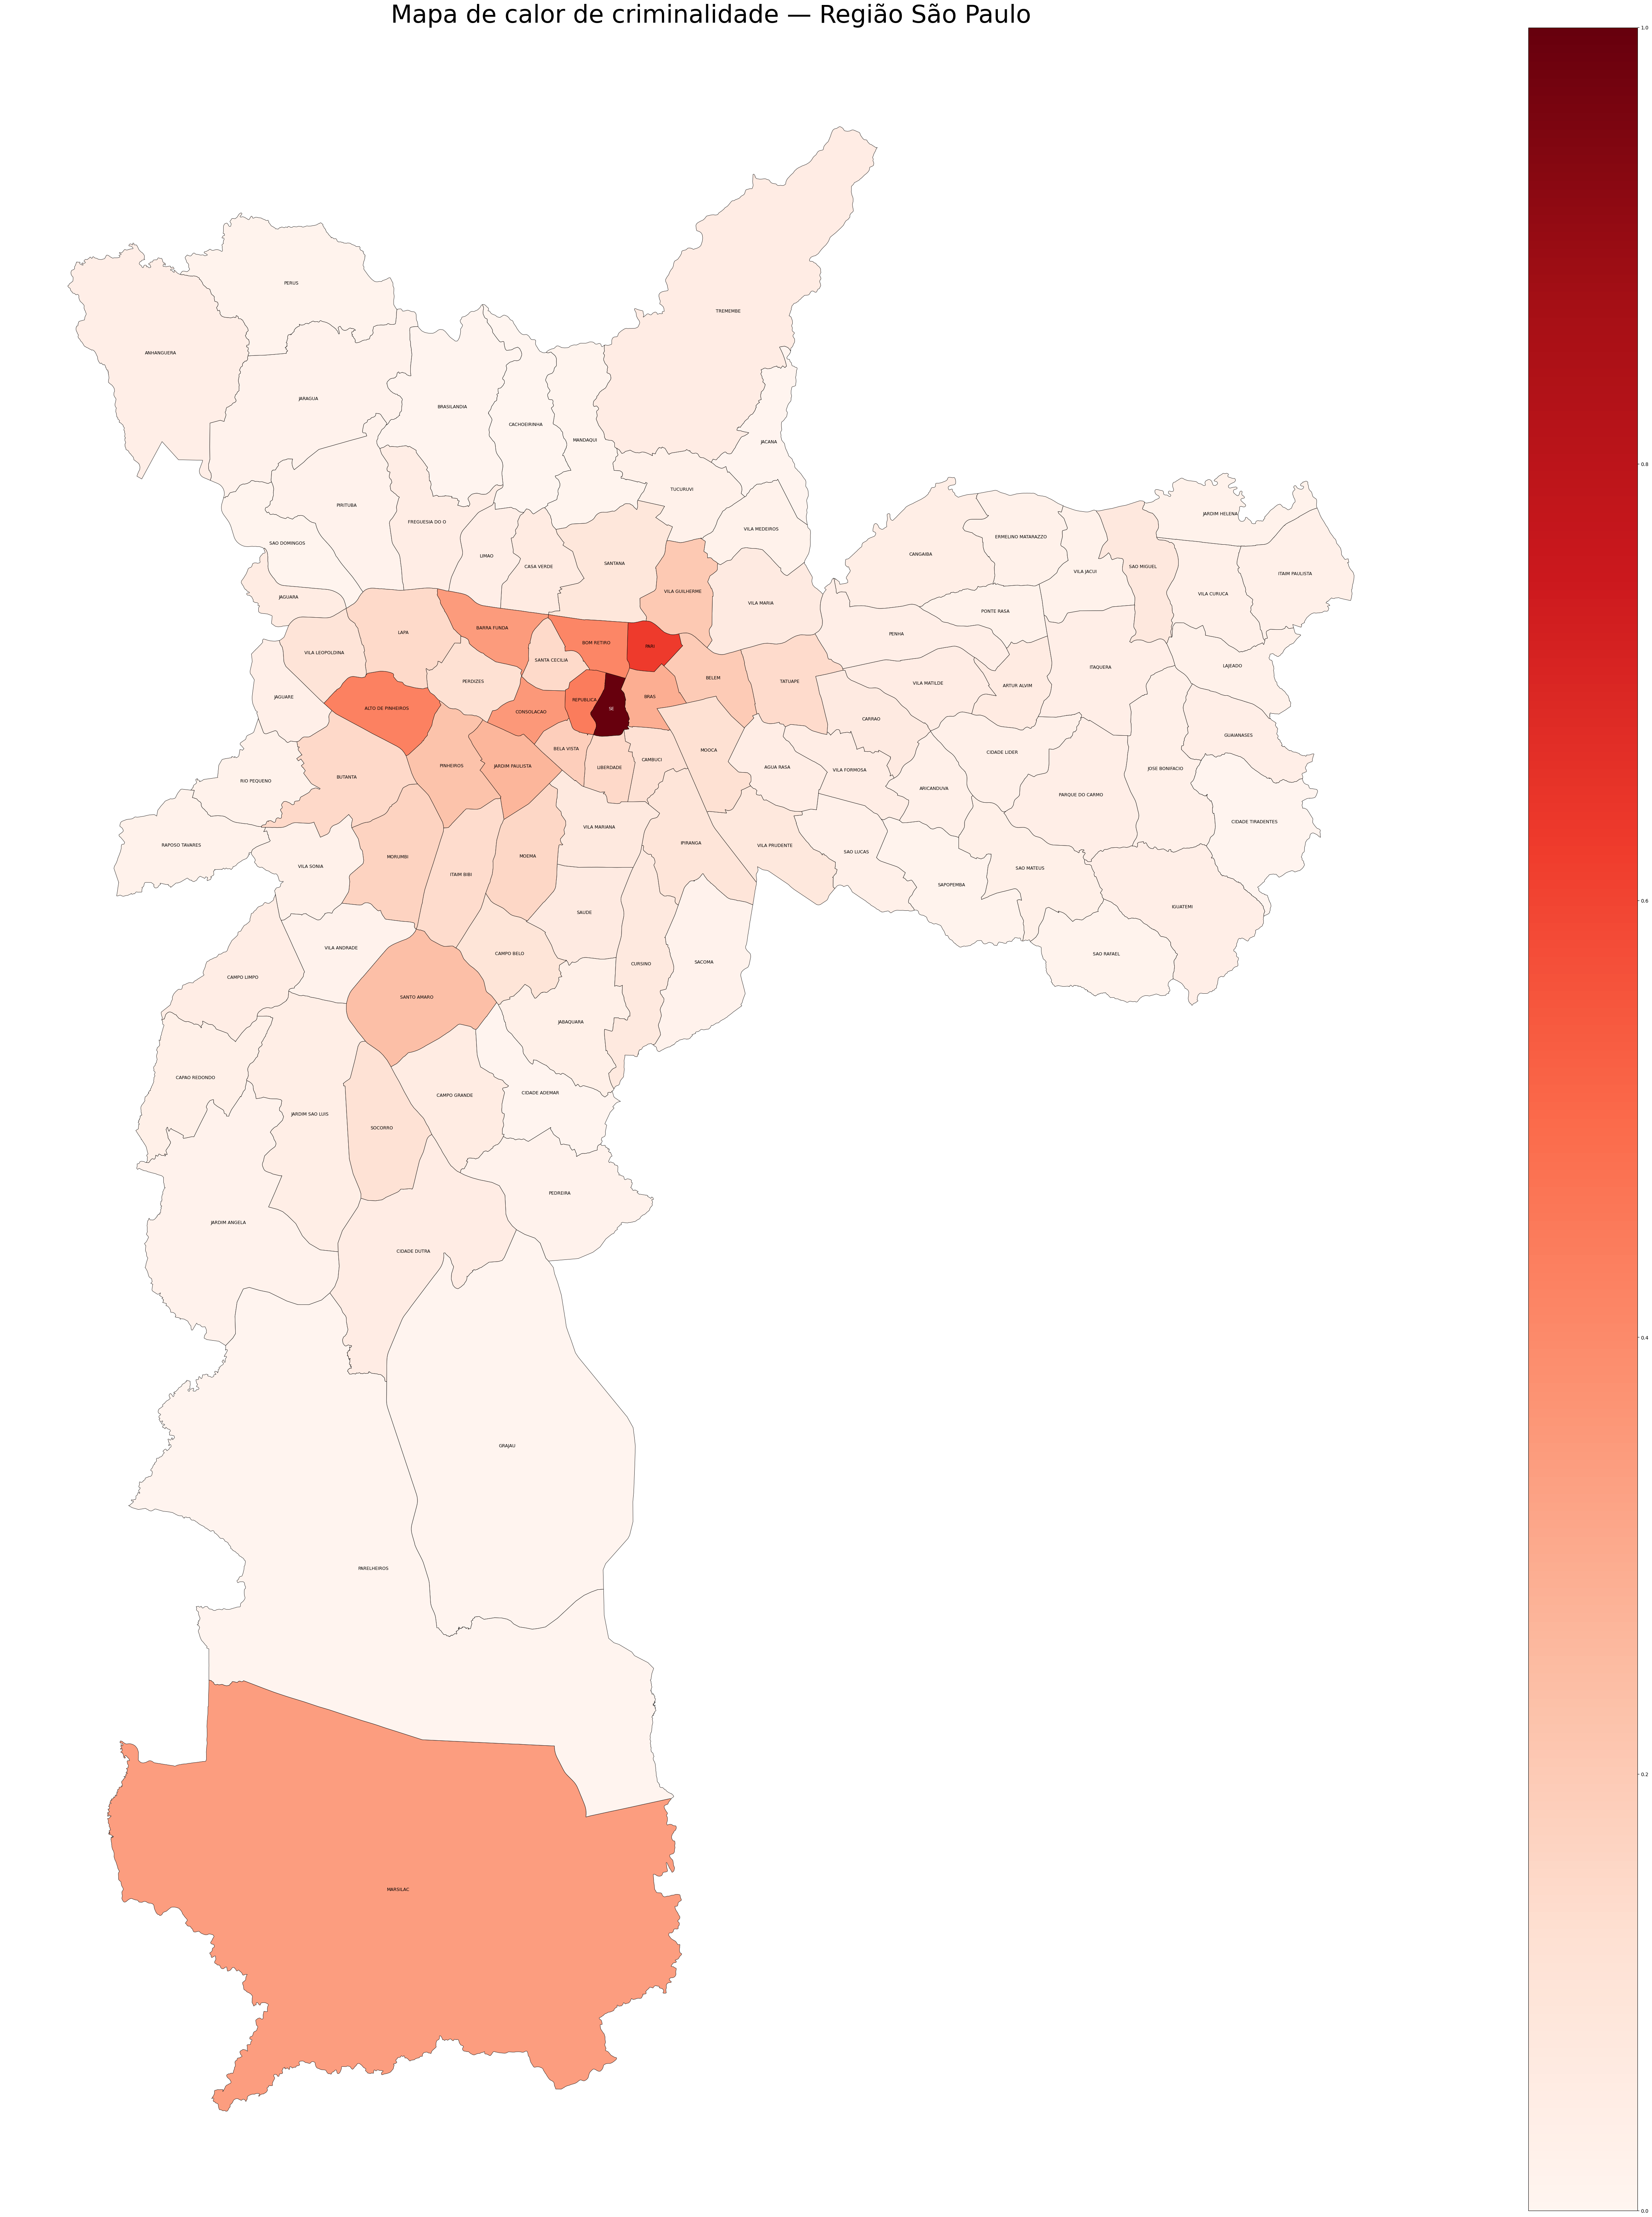

In [48]:
plotar_mapa(gdf_mapa, "São Paulo")